# Laboratorio 3 - Visión por Computadora

- Diego Estuardo Lemus López - 21469
- José Pablo Kiesling Lange - 21581
- Herber Sebastián Silva Muñoz - 21764

In [74]:
import numpy as np
import matplotlib.pyplot as plt

import cv2 as cv

from skimage.feature import hog

from hog import Hog

In [75]:
image = cv.imread("assets/person.png")

In [76]:
k = 1
block_size = 8

In [77]:
hog_from_scratch = Hog(k, block_size)

## 1. Implementar una función en Python que acepte una imagen a colores, y haga las siguientes transformaciones: 

### Conversión de RGB a escala de grises

In [78]:
gray_image = hog_from_scratch.convert_rgb_to_gray(image)

### Reescalado (resize) a un tamaño (128k, 64k), (ratio 2:1)

In [79]:
image_resized = hog_from_scratch.resize_image_ratio_2_1(gray_image)

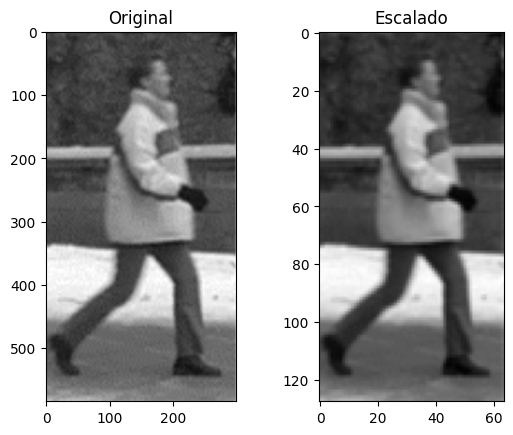

In [80]:
plt.subplot(1, 2, 1)
plt.title("Original")
plt.imshow(image, cmap='gray')
plt.subplot(1, 2, 2)
plt.title("Escalado")
plt.imshow(image_resized, cmap='gray')
plt.show()

## 2. Implementar una función en Python que calcule la magnitud del y ángulo del gradiente de una imagen en escala de grises. Internamente su algoritmo debe calcular las correlaciones Gx = I ∗ ∇x y Gy = I ∗ ∇y de la imagen con los filtros de Prewitt o de Sobel.

In [81]:
magnitude, angle = hog_from_scratch.calculate_image_gradient(image_resized)

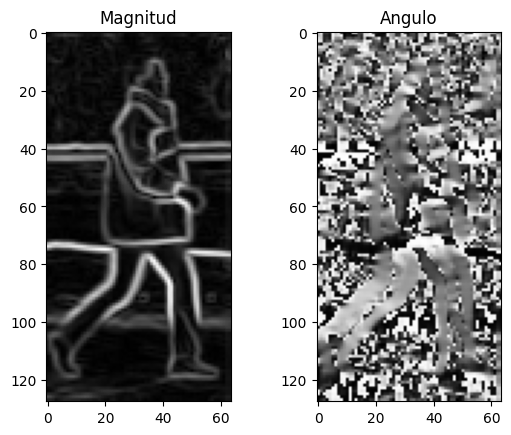

In [82]:
plt.subplot(1, 2, 1)
plt.title("Magnitud")
plt.imshow(magnitude, cmap='gray')
plt.subplot(1, 2, 2)
plt.title("Angulo")
plt.imshow(angle, cmap='gray')

## 3. Implementar una función en Python que construya el stack de bloques de tamaño block size × block size, usando un stride de block size//2. En este caso, block size debe ser un parámetro indicado por el usuario (se sugiere que sea un múltiplo de 4, e.g. 4 × 4, 8 × 8, 16 × 16). La entrada de la función debe ser la imagen µ y θ obtenidas del gradiente, y su función debe devolver dos stack o numpy arrays de tamaño MN×block size × block size, uno para la magnitud y otros para el ángulo del gradiente.

In [83]:
block_stack_magnitude = hog_from_scratch.build_block_stack(magnitude)
block_stack_angle = hog_from_scratch.build_block_stack(angle)

In [84]:
print(block_stack_magnitude.shape)

(465, 8, 8)


## 4. Implementar una función en Python que construya el histograma de gradientes, a partir de los stacks de bloques µ y θ. La construcción del histograma debe recibir un número de bines n indicado por el usuario (se sugiere usar n = 9). Internamente la función deberá calcular los centros de cada bin, y hacer un barrido de cada uno de los bloques en los stacks. Para cada bloque, debe calcularse un vector (numpy array de tamaño n) donde se guardará la información de su respectivo histograma.

In [85]:
histograms = hog_from_scratch.calculate_histogram(block_stack_magnitude, block_stack_angle)

In [86]:
print(histograms.shape)

(465, 9)


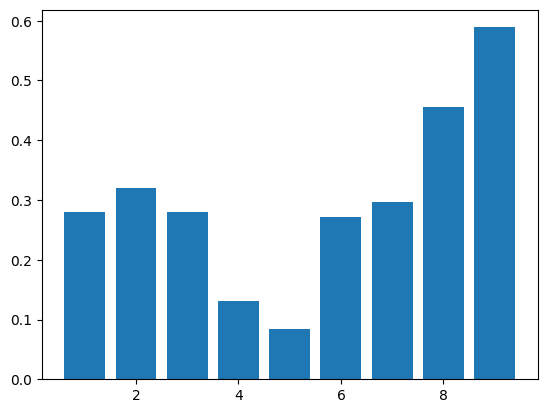

In [87]:
plt.figure()
plt.bar(x=np.arange(1,10), height=histograms[0])
plt.show()

In [88]:
rows = (image_resized.shape[0] // 8) - 1
cols = (image_resized.shape[1] // 8) - 1

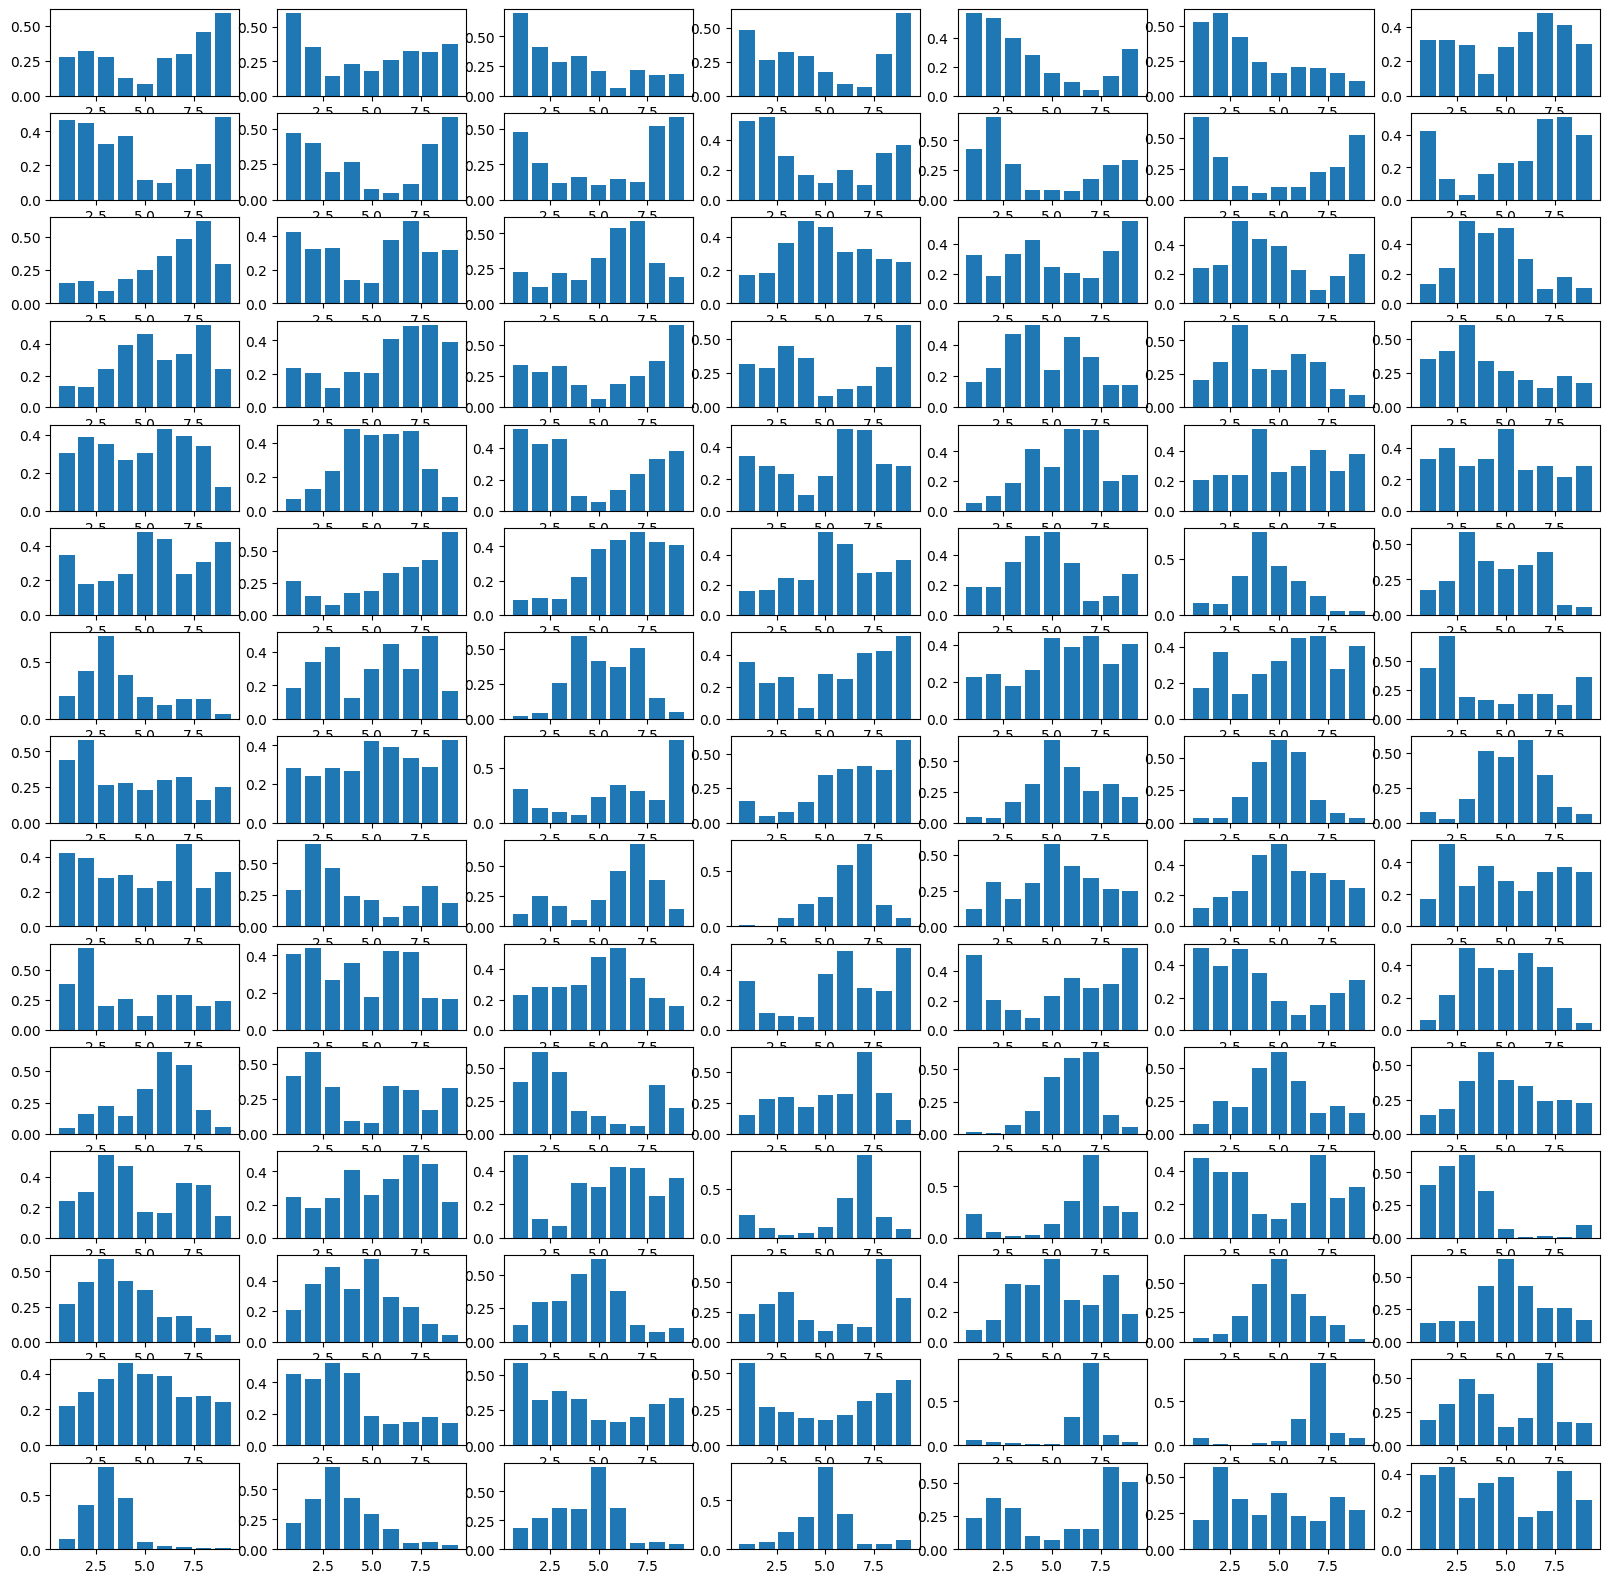

In [89]:
plt.figure(figsize=(20,20))
for i in range(0, rows):
    for j in range(0, cols):
        plt.subplot(rows, cols, cols*i+j+1)
        plt.bar(x=np.arange(1,10), height=histograms[i*cols+j])
plt.show()

## 5. Escribir una función en python que a cada bloque en el stack, convierta el histograma de ese bloque a un representación visual. Esta representación visual será una matriz de tamaño block size × block size. Esta imagen se trabaja como una imagen con fondo negro. Por cada índice en el histograma de dicho bloque, i = 1, 2, . . . , n, se dibujará una línea con ángulo en el centroide Ci del bin i, y de magnitud o intensidad igual al valor del histograma en el bin i.

In [90]:
direction = hog_from_scratch.build_directional_histogram(image_resized, histograms, num_bins=9, block_threshold=1.0,angle_min=45.0,angle_max=170.0)

In [91]:
rows = (image_resized.shape[0] // 8) - 1
cols = (image_resized.shape[1] // 8) - 1

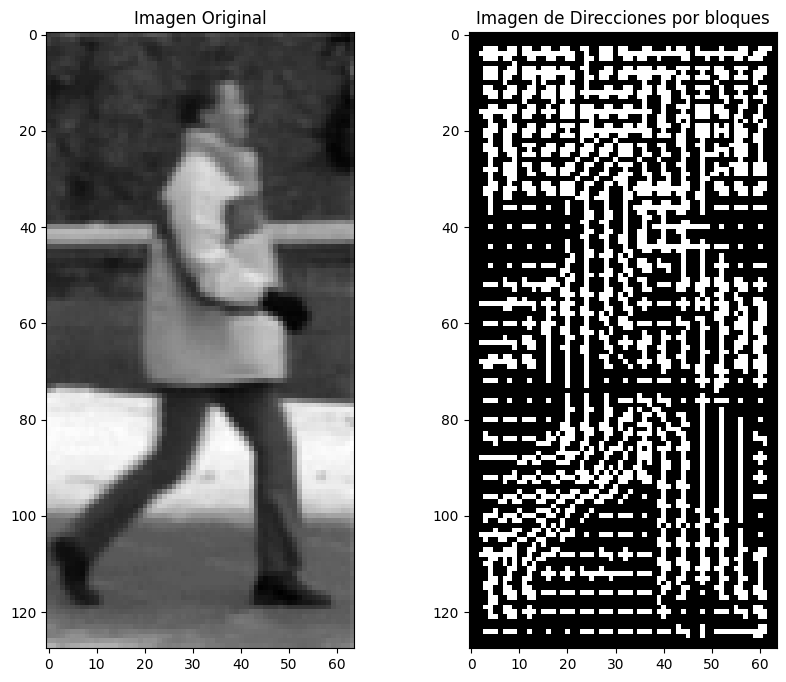

In [92]:
fig = plt.figure(figsize=(10,8))
plt.subplot(1,2,1)
plt.imshow(image_resized, cmap='gray')
plt.title('Imagen Original')
plt.subplot(1,2,2)
plt.imshow(direction, cmap='gray')
plt.title('Imagen de Direcciones por bloques')
plt.show()

## 6. Comparar sus resultados del algoritmo anterior (Ejercicios 1 a 5), contra la función de scikit-image hog.

In [93]:
fd, hogI = hog(image_resized, orientations=9, pixels_per_cell=(8, 8), cells_per_block=(2, 2), visualize=True)

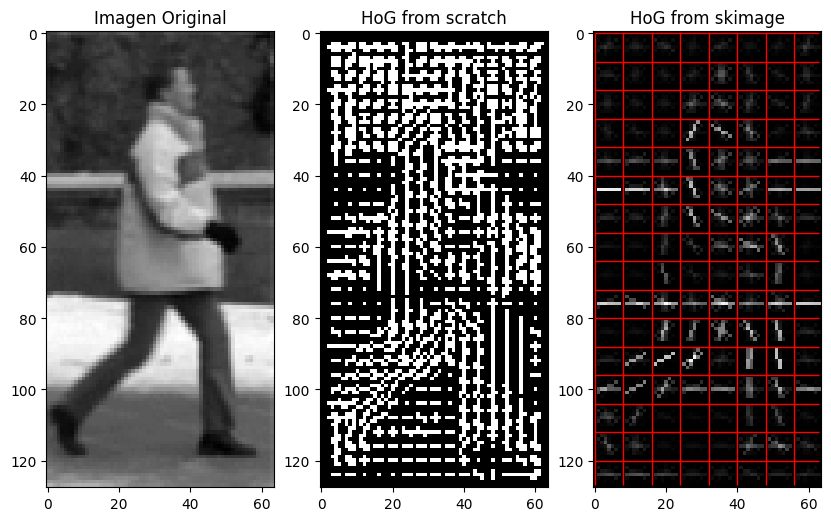

In [94]:
fig = plt.figure(figsize=(10,8))
plt.subplot(1,3,1)
plt.imshow(image_resized, cmap='gray')
plt.title('Imagen Original')
plt.subplot(1,3,2)
plt.imshow(direction, cmap='gray')
plt.title('HoG from scratch')
plt.subplot(1,3,3)
plt.imshow(hogI, cmap='gray')
plt.imshow(np.log(1.+hogI), cmap='gray')
plt.vlines(x=np.linspace(0,64*k-8,cols+1), ymin=0, ymax=128*k-1, lw=1, color='red')
plt.hlines(y=np.linspace(0,128*k-8,rows+1), xmin=0, xmax=64*k-1, lw=1, color='red')
plt.title('HoG from skimage')
plt.show()

## 7. Implementar un método de detección de personas, utilizando la librería de OpenCV. Mostrar resultados de su detección con diferentes imágenes de su elección.

In [95]:
paths = ["normal.jpg", "star-wars.jpg", "volei.jpeg", "dexter.jpg"]
paths = [f"assets/{path}" for path in paths]

In [96]:
images = [cv.imread(path) for path in paths]

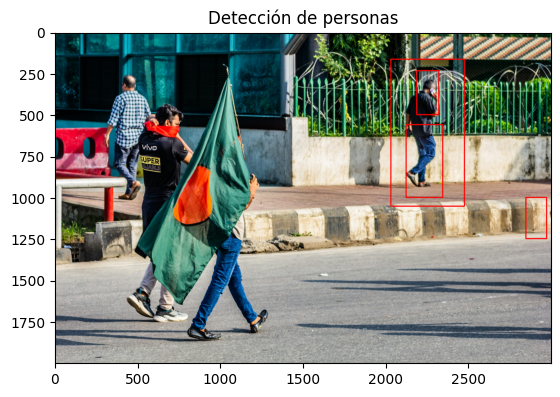

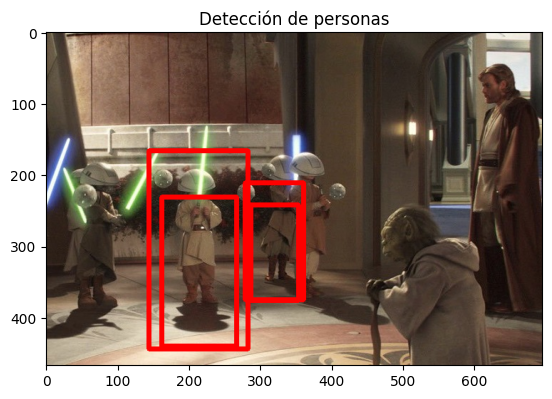

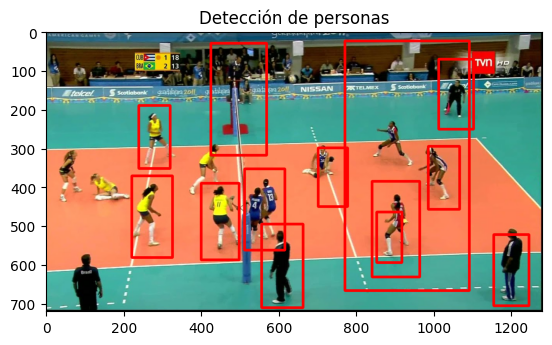

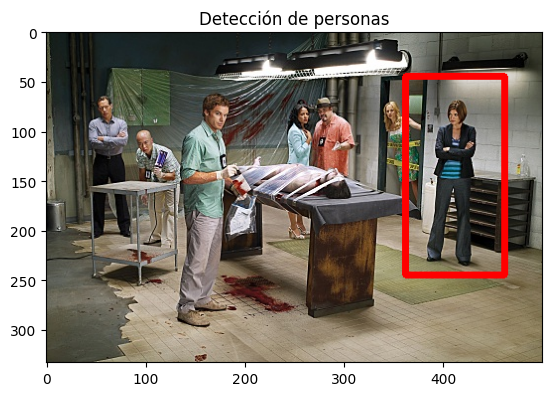

In [97]:
hog2 = cv.HOGDescriptor()
hog2.setSVMDetector(cv.HOGDescriptor_getDefaultPeopleDetector())

for image in images:

    locations, confidence = hog2.detectMultiScale(image)

    for (x, y, w, h) in locations:
        cv.rectangle(image, (x, y), (x + w, y + h), (0, 0, 255), 5)
    image = cv.cvtColor(image, cv.COLOR_BGR2RGB)
    plt.figure()
    plt.imshow(image)
    plt.title("Detección de personas")
    plt.show()